In [13]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from PIL import Image
import numpy as np

Getting [0...1] bitmap from image


In [14]:
img = Image.open("img/Kolo.jpg")

#plt.imshow(img, aspect='auto')
#plt.title('obraz wejściowy')
#plt.show()

grayscale_img = img.convert("L")

bitmap = np.array(grayscale_img)/255

Algorytm Bresenhama


In [15]:
def Breshenham(x0,y0,x1,y1):
    points = []
    
    delta_x = abs(x1 - x0)
    delta_y = abs(y1 - y0)
    
    direction_x = 1 if x0 < x1 else -1
    direction_y = 1 if y0 < y1 else -1
    
    error = delta_x - delta_y

    while True:
        points.append((x0, y0))
        
        if x0 == x1 and y0 == y1:
            break
            
        error_x2 = 2 * error
        
        #horizontal move
        if error_x2 > -delta_y:
            error -= delta_y
            x0 += direction_x
            
        #vertical mvoe
        if error_x2 < delta_x:
            error += delta_x
            y0 += direction_y
            
    return points

definiowanie wartosci


In [16]:
H, W = bitmap.shape
cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
R = min(W, H) / 2.0

n_detektorow = 180
delta_alpha  = 1.0   # krok kąta w stopniach
angles       = np.arange(0, 180, delta_alpha)       # [0, 1, 2, ..., 179]
offsets      = np.linspace(-R, R, n_detektorow)     # pozycje detektorów


wyznaczanie sinogramu


In [17]:
def generate_sinogram(angles, offsets, H, W):
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    sinogram = np.zeros((len(angles), n_detektorow))
    for i, alpha_deg in enumerate(angles):
        alpha = np.radians(alpha_deg)
        cos_a, sin_a = np.cos(alpha), np.sin(alpha)
        dx_p, dy_p   = -sin_a, cos_a          # oś prostopadła (gdzie siedzą detektory)

        for j, offset in enumerate(offsets):
            mx = cx + offset * dx_p
            my = cy + offset * dy_p

            t  = max(W, H)
            x0 = int(round(mx - t * cos_a))
            y0 = int(round(my - t * sin_a))
            x1 = int(round(mx + t * cos_a))
            y1 = int(round(my + t * sin_a))

            pixels = Breshenham(x0, y0, x1, y1)

            sinogram[i, j] = sum(
                bitmap[py, px]
                for px, py in pixels
                if 0 <= px < W and 0 <= py < H   # ← filtruj punkty poza obrazem
            )
    sinogram /= sinogram.max()
    return sinogram

Sinogram

In [18]:
#plt.imshow(sinogram, cmap='gray', aspect='auto')
#plt.xlabel('numer detektora')
#plt.ylabel('kąt α [°]')
#plt.title('sinogram')
#plt.show()

Rekonstrukcja


In [19]:
def backproject(sinogram, angles, n_detektorow, l_rozpietosc, H, W):
    reconstruction = np.zeros((H, W))
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    
    # Siatka współrzędnych obrazu
    x = np.linspace(-cx, W - 1 - cx, W)
    y = np.linspace(-cy, H - 1 - cy, H)
    X, Y = np.meshgrid(x, y)

    # Rozpiętość układu (l) definiuje zakres detektorów
    R_limit = l_rozpietosc / 2.0
    
    for i, alpha_deg in enumerate(angles):
        alpha = np.radians(alpha_deg)
        # s = x*cos(alpha) + y*sin(alpha)
        s = X * np.cos(alpha) + Y * np.sin(alpha)
        
        # Mapowanie s na indeksy detektorów w oparciu o aktualne l i n
        # Mapujemy zakres [-R_limit, R_limit] na [0, n_detektorow-1]
        detector_idx = (s + R_limit) * (n_detektorow - 1) / (2 * R_limit)
        
        # Interpolacja wartości z sinogramu
        proj_values = np.interp(detector_idx, np.arange(n_detektorow), sinogram[i, :], left=0, right=0)
        reconstruction += proj_values

    return reconstruction

Zrekonstruowany obraz


In [20]:
#plt.imshow(reconstruction, aspect='auto')
#plt.title('zrekonstruowany obraz')
#plt.show()

ValueError: operands could not be broadcast together with shapes (400,400) (180,) 

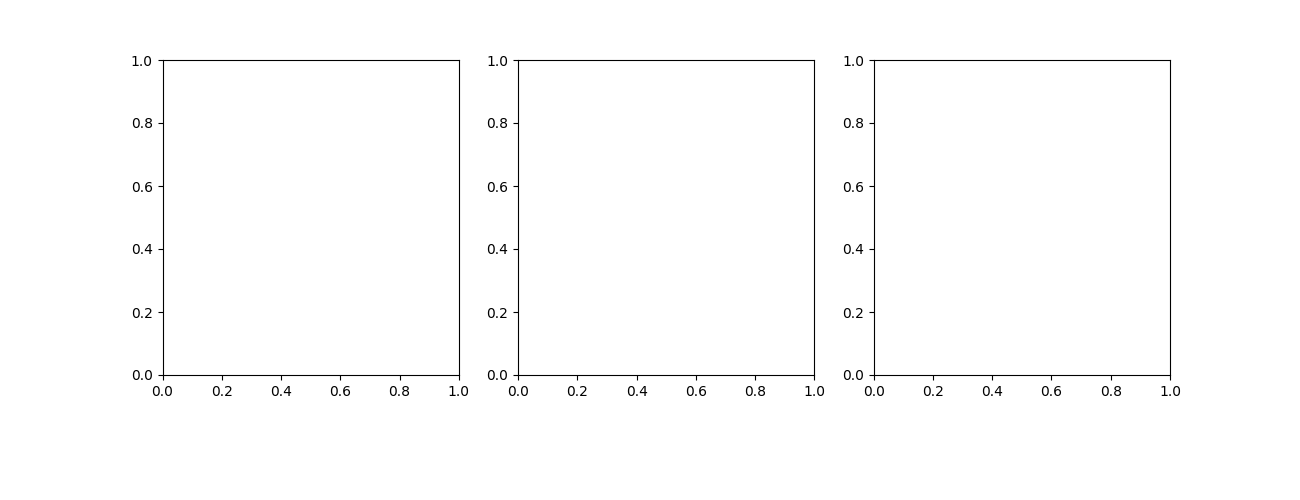

In [24]:
%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
plt.subplots_adjust(bottom=0.25)

sinogram = generate_sinogram(angles, offsets,H,W)
reconstructed = backproject(sinogram, angles, offsets, 20, H, W)

def rysuj(n):
    
    axes[0].cla()
    axes[1].cla()
    axes[2].cla()
    
    axes[0].imshow(bitmap, cmap='gray')
    axes[1].imshow(sinogram[:n], cmap='gray', aspect='auto')
    axes[2].imshow(reconstructed[:n], cmap='gray')
    
    axes[0].set_title('oryginał')
    axes[1].set_title(f'sinogram ({n}/{len(angles)} kątów)')
    axes[2].set_title(f'rekonstrukcja ({n}/{len(angles)} kątów)')
    
    axes[0].axis('off')
    axes[1].axis('off')
    axes[2].axis('off')
    
    fig.canvas.draw_idle()

# ── suwak ─────────────────────────────────────────────────
ax_suwak = plt.axes([0.2, 0.12, 0.6, 0.03])
suwak = Slider(ax_suwak, 'Kąt', 1, len(angles), valinit=1, valstep=1)

def on_suwak(val):
    rysuj(int(suwak.val))
    print(int(suwak.val))

suwak.on_changed(on_suwak)

# ── przycisk pełny wynik ──────────────────────────────────
ax_btn = plt.axes([0.4, 0.04, 0.2, 0.06])
btn = Button(ax_btn, 'Generuj pełny wynik')

def on_btn(event):
    suwak.set_val(len(angles))

btn.on_clicked(on_btn)

# ── start ─────────────────────────────────────────────────
rysuj(1)
plt.show()